# 04 — Patient Trajectories (Fase 3D)

Mapea riesgo(t) a las bandas de FASE 1 y analiza las **rutas clínicas** y la **matriz de transición** (Markov). El riesgo se suaviza (media móvil) para que las transiciones reflejen tendencia, no ruido.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


In [2]:
tj = load(MET/'trajectories.json')
print('Tipos de trayectoria:', tj['trajectory_types'])
print('Transiciones a peor precedidas por evento agudo:',
      f"{tj['events_before_upgrades']['pct_con_evento_previo']:.0%}")
pd.DataFrame(tj['transition_matrix'], index=tj['bands'], columns=tj['bands'])

Tipos de trayectoria: {'Sin transiciones': 135, 'Oscila': 121, 'Empeora': 79, 'Mejora': 65}
Transiciones a peor precedidas por evento agudo: 5%


,Bajo,Moderado,Alto,Muy Alto
Bajo,0.000,0.967,0.033,0.000
Moderado,0.474,0.000,0.522,0.004
Alto,0.000,0.472,0.000,0.528
Muy Alto,0.000,0.000,1.000,0.000


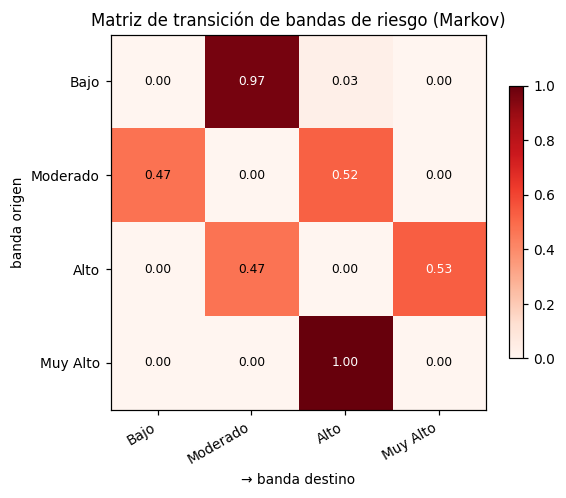

In [3]:
show(FIG/'trajectories'/'transition_matrix.png')

## Rutas de ejemplo

In [4]:
for r in tj['example_routes']: print(' ', r)

  Muy Alto → Alto → Moderado → Bajo
  Muy Alto → Alto → Muy Alto → Alto → Muy Alto → Alto → Muy Alto
  Bajo → Moderado → Bajo → Moderado → Bajo → Moderado
  Muy Alto → Alto → Moderado → Bajo
  Muy Alto → Alto → Moderado → Bajo
  Alto → Moderado → Alto → Muy Alto
  Moderado → Alto → Moderado → Alto
  Muy Alto → Alto → Muy Alto


### Conclusión 3D
La matriz de transición cuantifica la probabilidad de moverse entre bandas; la mayoría de transiciones son graduales (tendencia), no por eventos agudos aislados.